# Laboratorio 7 — Spark MLlib
## Modelado supervisado: Pipeline de Regresión Lineal (Secciones 5, 7 y 8)

Basado del análisis
exploratorio (`personas_2025_preparado.parquet` y `personas_2026_preparado.parquet`) y
resuelve, únicamente para el algoritmo de Regresión Lineal, las siguientes secciones
del enunciado:

- 5. Pipeline de regresión lineal
- 7. Entrenamiento final y evaluación en 2026. La parte correspondiente al
  modelo de Regresión Lineal (Random Forest en el otro notebook)
- 8. Visualización y análisis de errores. (Random Forest en el otro notebook)

No se realiza ningún preprocesamiento adicional de los datos crudos: se reutiliza
exactamente el DataFrame limpio y filtrado  ya generado, para evitar
incongruencias entre ambas partes del trabajo.


## 0. Configuración inicial y carga de datos preparados

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("Lab7_ENEIC_RegresionLineal")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

mydir = "/opt/app/working_dir/lab7/"


In [24]:
# Se carga el conjunto ya preparado
df_2025 = spark.read.parquet(mydir + "preparado/personas_2025_preparado.parquet")
df_2026 = spark.read.parquet(mydir + "preparado/personas_2026_preparado.parquet")

df_2025.printSchema()
df_2025.show(5)


root
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- P02A03: long (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- cat

### Predictores y variable objetivo

Como dice el PDF, se usan exactamente 6 predictores:
`edad`, `antiguedad`, `horas_semanales` (numéricos) y `nivel_educativo`,
`categoria_ocupacional`, `dominio` (categóricos), para estimar `salario_mensual`.
No se incluyen identificadores, el factor de expansión, otros montos de ingreso,
el salario por hora ni la etiqueta de clúster.

In [39]:
NUMERICAS = ["edad", "antiguedad", "horas_semanales"]
CATEGORICAS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
LABEL = "salario_mensual"

COLUMNAS_MODELO = NUMERICAS + CATEGORICAS + [LABEL, "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

# No arrastrar nulos en las columnas relevantes para el modelo (se supone no debería tener por el preprocesamiento, pero por si acaso porque si no truena)
df_2025_modelo = df_2025.select(*COLUMNAS_MODELO).na.drop(subset=NUMERICAS + [LABEL])
df_2026_modelo = df_2026.select(*COLUMNAS_MODELO).na.drop(subset=NUMERICAS + [LABEL])

print("Registros 2025 disponibles para modelado:", df_2025_modelo.count())
print("Registros 2026 disponibles para modelado:", df_2026_modelo.count())


Registros 2025 disponibles para modelado: 53025
Registros 2026 disponibles para modelado: 13258


## 1. Partición train / validación / prueba

Siguiendo la tabla de uso de los archivos del enunciado:

| Período | Uso |
|---|---|
| 2025T1, 2025T2, 2025T3 | Desarrollo y entrenamiento |
| 2025T4 | Validación y, después de elegir hiperparámetros, se incorpora al entrenamiento final |
| 2026T1 | Prueba final (no se toca hasta la sección 7) |

Es decir: el entrenamiento y la búsqueda de configuración de regularización se hacen
con 2025T1–T3; la validación (para elegir la mejor configuración) se hace con 2025T4;
una vez elegida la configuración, se reentrena el modelo con todo 2025 (T1–T4) antes
de evaluar sobre 2026T1 en la sección 7.

In [26]:
df_train = df_2025_modelo.filter(F.col("periodo_archivo") != "2025T4")
df_val   = df_2025_modelo.filter(F.col("periodo_archivo") == "2025T4")

print("Entrenamiento (2025 T1-T3):", df_train.count())
print("Validación (2025 T4):", df_val.count())

df_train.groupBy("periodo_archivo").count().orderBy("periodo_archivo").show()


Entrenamiento (2025 T1-T3): 40361
Validación (2025 T4): 12664
+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|13419|
|         2025T2|13492|
|         2025T3|13450|
+---------------+-----+



## Modelo de referencia (baseline)

Como punto de comparación obligatorio se define un modelo de referencia naive:
predice para todas las personas el salario mensual promedio observado en el conjunto
de entrenamiento, sin usar ningún predictor. Cualquier modelo supervisado razonable
debería superar estas métricas.


In [27]:
def calcular_metricas(df_predicciones, label_col="salario_mensual", pred_col="prediccion", nombre_modelo=""):
    evaluator_rmse = RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="rmse")
    evaluator_mae  = RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="mae")
    evaluator_r2   = RegressionEvaluator(labelCol=label_col, predictionCol=pred_col, metricName="r2")
    return {
        "modelo": nombre_modelo,
        "n": df_predicciones.count(),
        "MAE": evaluator_mae.evaluate(df_predicciones),
        "RMSE": evaluator_rmse.evaluate(df_predicciones),
        "R2": evaluator_r2.evaluate(df_predicciones),
    }

media_train = df_train.select(F.mean(LABEL)).first()[0]
print(f"Salario promedio en entrenamiento (2025 T1-T3): Q{media_train:,.2f}")

df_val_baseline = df_val.withColumn("prediccion", F.lit(media_train))
metricas_baseline_val = calcular_metricas(df_val_baseline, nombre_modelo="Referencia (media) — validación")
pd.DataFrame([metricas_baseline_val])


Salario promedio en entrenamiento (2025 T1-T3): Q3,383.12


,modelo,n,MAE,RMSE,R2
0,Referencia (media) — validación,12664,1672.502606,2889.571432,-0.003132


## 2. Pipeline de Regresión Lineal (Sección 5)

El pipeline incluye, en este orden:

-  `StringIndexer` + `OneHotEncoder` para `nivel_educativo`, `categoria_ocupacional` y `dominio`.
   Se usa `handleInvalid="keep"` para que categorías no vistas en entrenamiento (por ejemplo,
   un código de `dominio` que solo aparece en 2026) no rompan el pipeline en validación/prueba.
-  `VectorAssembler` que combina los tres numéricos (`edad`, `antiguedad`, `horas_semanales`)
   con los tres vectores one-hot.
-  Estandarización de los predictores mediante la opción interna `standardization=True` de
   `LinearRegression` (no se usa `StandardScaler` adicional, como permite el enunciado).
-  Un modelo `LinearRegression` para estimar `salario_mensual`.

In [28]:
indexers = [
    StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="keep")
    for c in CATEGORICAS
]
encoders = [
    OneHotEncoder(inputCol=c + "_idx", outputCol=c + "_ohe", handleInvalid="keep")
    for c in CATEGORICAS
]
assembler = VectorAssembler(
    inputCols=NUMERICAS + [c + "_ohe" for c in CATEGORICAS],
    outputCol="features",
)

def construir_pipeline_lr(regParam, elasticNetParam):
    lr = LinearRegression(
        featuresCol="features",
        labelCol=LABEL,
        predictionCol="prediccion",
        regParam=regParam,
        elasticNetParam=elasticNetParam,
        standardization=True,
    )
    return Pipeline(stages=indexers + encoders + [assembler, lr])


### Búsqueda de configuración de regularización

Se prueban al menos dos configuraciones de regularización (parámetro `regParam` y
`elasticNetParam`), ajustando todos los componentes del pipeline exclusivamente con
los datos de entrenamiento (2025 T1–T3), y evaluando el RMSE sobre el conjunto de
validación (2025 T4).

- `regParam=0.0` → regresión lineal sin regularización (referencia OLS).
- `regParam=0.1, elasticNetParam=0.0` → regularización tipo Ridge (L2).
- `regParam=0.1, elasticNetParam=0.5` → regularización elástica (mezcla L1/L2).

In [ ]:
configs_regularizacion = [
    {"regParam": 0.0, "elasticNetParam": 0.0},
    {"regParam": 0.1, "elasticNetParam": 0.0},
    {"regParam": 0.1, "elasticNetParam": 0.5},
]

resultados_val = []
modelos_entrenados = {}

for cfg in configs_regularizacion:
    pipeline = construir_pipeline_lr(**cfg)
    modelo = pipeline.fit(df_train)          # ajustado solo con datos de entrenamiento
    pred_val = modelo.transform(df_val)

    etiqueta = f"LR (regParam={cfg['regParam']}, elasticNetParam={cfg['elasticNetParam']})"
    metricas = calcular_metricas(pred_val, nombre_modelo=etiqueta)
    metricas.update(cfg)

    resultados_val.append(metricas)
    modelos_entrenados[(cfg["regParam"], cfg["elasticNetParam"])] = modelo

resultados_val_pd = pd.DataFrame(resultados_val).sort_values("RMSE").reset_index(drop=True)
resultados_val_pd


,modelo,n,MAE,RMSE,R2,regParam,elasticNetParam
0,"LR (regParam=0.0, elasticNetParam=0.0)",12664,1210.137480,2186.419579,0.425675,0.0,0.0
1,"LR (regParam=0.1, elasticNetParam=0.0)",12664,1210.132737,2186.420865,0.425674,0.1,0.0
2,"LR (regParam=0.1, elasticNetParam=0.5)",12664,1210.107022,2186.424785,0.425672,0.1,0.5


In [30]:
mejor_fila = resultados_val_pd.iloc[0]
best_regParam = float(mejor_fila["regParam"])
best_elasticNet = float(mejor_fila["elasticNetParam"])

print(f"Mejor configuración según RMSE de validación: regParam={best_regParam}, elasticNetParam={best_elasticNet}")
print(f"RMSE de validación: {mejor_fila['RMSE']:.2f}  |  MAE: {mejor_fila['MAE']:.2f}  |  R2: {mejor_fila['R2']:.4f}")


Mejor configuración según RMSE de validación: regParam=0.0, elasticNetParam=0.0
RMSE de validación: 2186.42  |  MAE: 1210.14  |  R2: 0.4257


El mejor resultado en esta etapa de Validation es el LR con regParam=0.0 y elasticNetParam=0.0; básicamente, la regresión lineal más "pura"; no obstante, ambos 3 resultados presentados en la tabla anterior mantienen un desempeño similar, pues esta aclaración de "es mejor" es por variaciones realmente leves. 

Todos los 3 modelos de regresión sobrepasan en desempeño al "modelo naive" (que es la media de la muestra)

## 3. Entrenamiento final del modelo (2025 completo)

Para la configuración de regularización con menor RMSE de validación,
se reentrena el pipeline usando todo el año 2025 (T1–T4), de acuerdo con la tabla del
enunciado PDF, que indica que 2025T4 se usa para validación y, posteriormente, para el
entrenamiento final. El primer trimestre de 2026 se reserva intacto para la evaluación
de la sección 7.

In [31]:
df_2025_full = df_train.unionByName(df_val)
print("Registros usados en el entrenamiento final (2025 completo):", df_2025_full.count())

pipeline_final_lr = construir_pipeline_lr(best_regParam, best_elasticNet)
modelo_lr_final = pipeline_final_lr.fit(df_2025_full)

# Guardamos el modelo para que quede disponible para el resto del equipo / la sección 7
ruta_modelo_lr = mydir + "modelos/regresion_lineal_final"
modelo_lr_final.write().overwrite().save(ruta_modelo_lr)
print("Modelo final de Regresión Lineal guardado en:", ruta_modelo_lr)


Registros usados en el entrenamiento final (2025 completo): 53025


Modelo final de Regresión Lineal guardado en: /opt/app/working_dir/lab7/modelos/regresion_lineal_final


## 4. Entrenamiento final y evaluación en 2026 (Inciso 7) — parte de Regresión Lineal

Se generan predicciones sobre el primer trimestre de 2026 (reglas de preparación declaradas en el notebook inicial) y se evalúan con las mismas métricas
(MAE, RMSE, R²) usadas en validación, tanto para el modelo de referencia como para la
Regresión Lineal.

> La tabla `tabla_comparacion_test` con las filas
> de "Referencia (media)" y "Regresión Lineal", pues este notebook solo es de la RL.
> la comparación con el otro algoritmo (RF) se encuentra en el otro notebook.

In [ ]:
df_test = df_2026_modelo
print("Registros de prueba elegibles (2026 T1):", df_test.count())

# Modelo de referencia sobre 2026 
media_final = df_2025_full.select(F.mean(LABEL)).first()[0]
df_test_baseline = df_test.withColumn("prediccion", F.lit(media_final))
metricas_baseline_test = calcular_metricas(df_test_baseline, nombre_modelo="Referencia (media)")

#  Regresión Lineal sobre 2026 
pred_test_lr = modelo_lr_final.transform(df_test)
metricas_lr_test = calcular_metricas(pred_test_lr, nombre_modelo="Regresión Lineal")

tabla_comparacion_test = pd.DataFrame([metricas_baseline_test, metricas_lr_test])
tabla_comparacion_test


Registros de prueba elegibles (2026 T1): 13258


,modelo,n,MAE,RMSE,R2
0,Referencia (media),13258,1718.086005,2871.420677,-0.002525
1,Regresión Lineal,13258,1240.710547,2163.751703,0.430732


Como se vio venir por la sección de Validation, en esta de Test se observa que la Regresión Lineal tiene mejor desempeño que el modelo base elegido para este caso (media del conjunto de datos). Ganando en los 3 medidores (MAE, RMSE, R2), se declara un claro ganador entre ambos. 
No obstante, esto no significa que la Regresión Lineal sea buena para predecir y tratar con este conjunto de datos, pues tener dichos valores de MAE, RMSE y R2 no representan un buen modelo que solucione el planteamiento de lo que se pretende predecir. Por tanto, aunque sí es mejor utilizar una Regresión Lineal que un simple promedio de datos, se debería buscar otro modelo o algoritmo que pueda solucionar satisfactoriamente este problema.

## 5. Visualización y análisis de errores — Regresión Lineal (Sección 8)

Se define el residuo como:

$$\text{residuo} = \text{salario real} - \text{salario predicho}$$

De forma que un residuo positivo indica subestimación (el modelo predijo por debajo
del valor real) y un residuo negativo indica sobreestimación.

Para los gráficos se usa una muestra reproducible de hasta 5,000 registros del conjunto
de prueba; las métricas por grupo (nivel educativo y dominio) se calculan sobre todos
los registros de prueba, no sobre la muestra.

In [33]:
pred_test_lr_full = (
    pred_test_lr
    .withColumn("residuo", F.col(LABEL) - F.col("prediccion"))
    .withColumn("error_abs", F.abs(F.col("residuo")))
)

n_test = pred_test_lr_full.count()
fraccion_muestra = min(1.0, 5000 / n_test)

muestra_lr_pd = (
    pred_test_lr_full
    .select(LABEL, "prediccion", "residuo", "nivel_educativo", "dominio")
    .sample(withReplacement=False, fraction=fraccion_muestra, seed=42)
    .limit(5000)
    .toPandas()
)
print("Tamaño de la muestra usada para graficar:", len(muestra_lr_pd))


Tamaño de la muestra usada para graficar: 5000


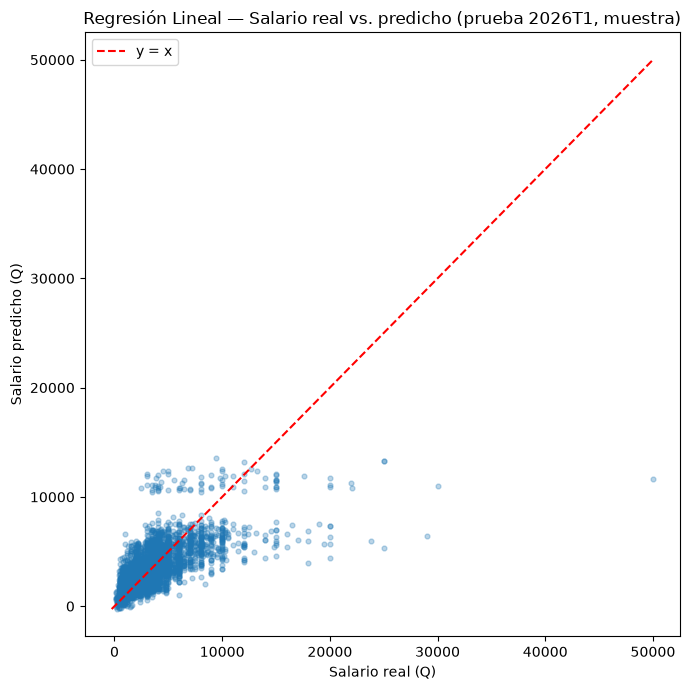

In [34]:
# 1) Salario real vs. salario predicho, con línea de referencia y = x
plt.figure(figsize=(7, 7))
plt.scatter(muestra_lr_pd[LABEL], muestra_lr_pd["prediccion"], alpha=0.3, s=12)

lim_min = min(muestra_lr_pd[LABEL].min(), muestra_lr_pd["prediccion"].min())
lim_max = max(muestra_lr_pd[LABEL].max(), muestra_lr_pd["prediccion"].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], color="red", linestyle="--", label="y = x")

plt.xlabel("Salario real (Q)")
plt.ylabel("Salario predicho (Q)")
plt.title("Regresión Lineal — Salario real vs. predicho (prueba 2026T1, muestra)")
plt.legend()
plt.tight_layout()
plt.show()


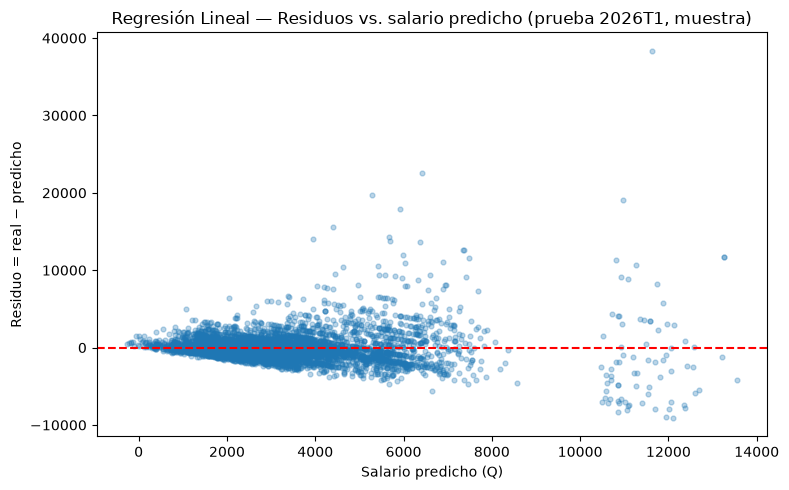

In [35]:
# 2) Residuos vs. salario predicho, con línea horizontal en cero
plt.figure(figsize=(8, 5))
plt.scatter(muestra_lr_pd["prediccion"], muestra_lr_pd["residuo"], alpha=0.3, s=12)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Salario predicho (Q)")
plt.ylabel("Residuo = real − predicho")
plt.title("Regresión Lineal — Residuos vs. salario predicho (prueba 2026T1, muestra)")
plt.tight_layout()
plt.show()


### Tabla de MAE y error medio por nivel educativo y por dominio

Calculadas sobre todos los registros de prueba (no la muestra usada para graficar).

In [36]:
tabla_error_nivel_educ = (
    pred_test_lr_full.groupBy("nivel_educativo")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean("error_abs"), 2).alias("MAE"),
        F.round(F.mean("residuo"), 2).alias("error_medio"),
    )
    .orderBy("nivel_educativo")
    .toPandas()
)
tabla_error_nivel_educ


,nivel_educativo,n,MAE,error_medio
0,0,1016,823.51,109.34
1,1,80,735.21,88.76
2,2,3957,870.04,54.56
3,3,2164,894.45,127.77
4,4,4117,1109.31,103.98
5,5,1729,2566.37,295.51
6,6,183,5552.88,-131.50
7,7,12,12919.31,6062.70


In [37]:
tabla_error_dominio = (
    pred_test_lr_full.groupBy("dominio")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean("error_abs"), 2).alias("MAE"),
        F.round(F.mean("residuo"), 2).alias("error_medio"),
    )
    .orderBy("dominio")
    .toPandas()
)
tabla_error_dominio


,dominio,n,MAE,error_medio
0,1,5632,1446.09,136.04
1,2,4846,1189.65,134.28
2,3,2780,913.64,65.24


### Errores por tramo de salario (percentiles)

Para revisar si el modelo tiende a subestimar o sobreestimar salarios altos, se agrupan
los registros de prueba en tramos según los percentiles del salario real (calculados
sobre el conjunto de prueba completo) y se calcula el error medio y el MAE en cada tramo.

In [38]:
q25, q50, q75, q90 = pred_test_lr_full.approxQuantile(LABEL, [0.25, 0.5, 0.75, 0.9], 0.001)
print(f"Percentiles de salario real en prueba -> P25={q25:.0f}, P50={q50:.0f}, P75={q75:.0f}, P90={q90:.0f}")

pred_test_lr_full = pred_test_lr_full.withColumn(
    "grupo_salario",
    F.when(F.col(LABEL) <= q25, "P0-25")
     .when(F.col(LABEL) <= q50, "P25-50")
     .when(F.col(LABEL) <= q75, "P50-75")
     .when(F.col(LABEL) <= q90, "P75-90")
     .otherwise("P90-100"),
)

orden_grupo = F.when(F.col("grupo_salario") == "P0-25", 1) \
               .when(F.col("grupo_salario") == "P25-50", 2) \
               .when(F.col("grupo_salario") == "P50-75", 3) \
               .when(F.col("grupo_salario") == "P75-90", 4) \
               .otherwise(5)

tabla_error_percentil = (
    pred_test_lr_full
    .withColumn("_orden", orden_grupo)
    .groupBy("grupo_salario", "_orden")
    .agg(
        F.count("*").alias("n"),
        F.round(F.mean(LABEL), 0).alias("salario_real_prom"),
        F.round(F.mean("prediccion"), 0).alias("salario_predicho_prom"),
        F.round(F.mean("residuo"), 2).alias("error_medio"),
        F.round(F.mean("error_abs"), 2).alias("MAE"),
    )
    .orderBy("_orden")
    .drop("_orden")
    .toPandas()
)
tabla_error_percentil


Percentiles de salario real en prueba -> P25=2000, P50=3200, P75=4066, P90=6000


,grupo_salario,n,salario_real_prom,salario_predicho_prom,error_medio,MAE
0,P0-25,4032,1298.0,2126.0,-828.73,998.39
1,P25-50,2715,2738.0,2899.0,-161.09,851.68
2,P50-75,3188,3769.0,3849.0,-79.64,830.82
3,P75-90,2072,4889.0,4402.0,486.18,1177.65
4,P90-100,1251,9963.0,6267.0,3695.92,4015.04


Como se observa, el error medio predicho para los primeros 3 grupos de salario es negativo, indicando que el modelo sobrestima (predice de más) en su predicción, para los datos pertenecientes a este conjunto. Caso contrario ocurre en los últimos dos grupos, pues al tener valores positivos en error medio, indica que el modelo subestimó su predicción.   
Respecto al análisis de niveles educativos, el único que resalta es el último, pues tiene un error medio demasiado positivo y alto, indicando que el modelo subestimó demasiado el valor real. Dando a entender que el modelo, para los salarios altos, no es tan exacto. 

